① Transforms当成工具箱的话，里面的class就是不同的工具。例如像totensor、resize这些工具。

② Transforms拿一些特定格式的图片，经过Transforms里面的工具，获得我们想要的结果。
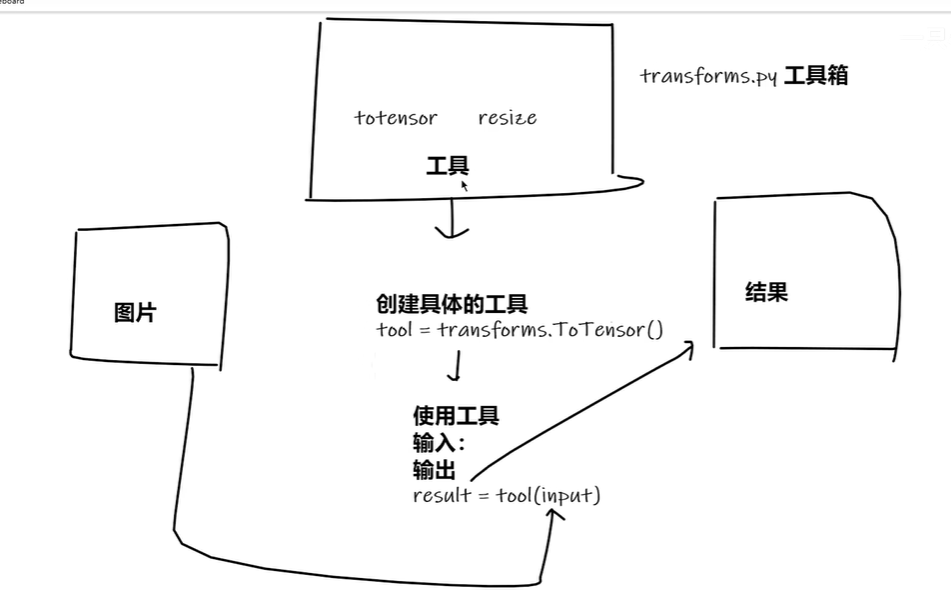

In [1]:
from torchvision import transforms
import torch
from PIL import Image
# transforms如何使用
img_path = "Data/train/ants_image/0013035.jpg"
 
img = Image.open(img_path)
print(img)

tensor_trans = transforms.ToTensor() #创建类，别再写成C++了
# 输入可以说PIL的也可以是opencv的
# 最终转为[0,1]之间的值
tensor_trans(img).shape

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x512 at 0x217968CE9B0>


torch.Size([3, 512, 768])

上述tensor打印的参数分别为：

    C：Channel，通道数，表示一张图像中的通道数

    H：Height，高度，表示图像垂直维度的像素数
    
    W：Width，宽度，表示图像水平维度的像素数

In [2]:
import cv2

cv2_img = cv2.imread(img_path)
tensor_trans(cv2_img)

tensor([[[0.9137, 0.9137, 0.9137,  ..., 0.9176, 0.9098, 0.8980],
         [0.9176, 0.9176, 0.9176,  ..., 0.9176, 0.9098, 0.8980],
         [0.9216, 0.9216, 0.9216,  ..., 0.9137, 0.9098, 0.9020],
         ...,
         [0.9294, 0.9294, 0.9255,  ..., 0.5529, 0.9216, 0.8941],
         [0.9294, 0.9294, 0.9255,  ..., 0.8863, 1.0000, 0.9137],
         [0.9294, 0.9294, 0.9255,  ..., 0.9490, 0.9804, 0.9137]],

        [[0.5922, 0.5922, 0.5922,  ..., 0.5961, 0.5882, 0.5765],
         [0.5961, 0.5961, 0.5961,  ..., 0.5961, 0.5882, 0.5765],
         [0.6000, 0.6000, 0.6000,  ..., 0.5922, 0.5882, 0.5804],
         ...,
         [0.6275, 0.6275, 0.6235,  ..., 0.3608, 0.6196, 0.6157],
         [0.6275, 0.6275, 0.6235,  ..., 0.5765, 0.6275, 0.5961],
         [0.6275, 0.6275, 0.6235,  ..., 0.6275, 0.6235, 0.6314]],

        [[0.3137, 0.3137, 0.3137,  ..., 0.3176, 0.3098, 0.2980],
         [0.3176, 0.3176, 0.3176,  ..., 0.3176, 0.3098, 0.2980],
         [0.3216, 0.3216, 0.3216,  ..., 0.3137, 0.3098, 0.

In [3]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("logs")

tensor_img = tensor_trans(img)

writer.add_image("Tensor_img", tensor_img)
writer.close()
# tensorboard --logdir=dir --port=port

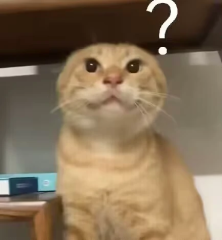

In [4]:
# 常见的transforms用法
# 输入 PIL
# 输出 tensor 
img1_path = "images/1.jpg"

img1 = Image.open(img1_path).convert('RGB')
img1

### call用法

In [5]:
class Person:
    def __call__(self, name):
        print("__call__"+"Hello"+name)
    def hello(self, name):
        print("hello" + name)
    
person = Person()
person('lisi') #相当于C++的构造函数
person.hello('wangda')

__call__Hellolisi
hellowangda


### 归一化
output[channel] = (input[channel] - mean[channel]) / std[channel]
原理就是下图
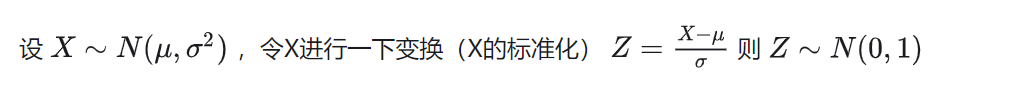

In [6]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("logs")
img1_tensor = tensor_trans(img1)
writer.add_image("img1",img1_tensor,0)
print(img1_tensor[0][0][0])
trans_norm = transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
img1_norm = trans_norm(img1_tensor)
writer.add_image("img1",img1_norm,1)
print(img1_norm[0][0][0])

tensor(0.6314)
tensor(0.2627)


### resize

In [ ]:
tensor_resize = transforms.Resize((512,512))
# 输入的为PIL数据，不同于前面的Tensor
img1_resize = tensor_resize(img1)

writer.add_image('img1',tensor_trans(img1_resize),2)
# return也是PIL
writer.close()
img1_resize.size


(512, 512)

### 随机裁剪RandomCrop

In [ ]:
trans_random = transforms.RandomCrop(12,12)
trans_compose = transforms.Compose([trans_random, tensor_trans])
# compose用法就是将一系列流程放入列表中，按顺序执行
for i in range(10):
    img_crop = trans_compose(img1)
    writer.add_image("RandomCrop", img_crop, i)
writer.close()